# ANN For telcom Churn prediction

Problem Statement: The goal is to predict customer churn for a telecom company.

This is a binary classification task where we predict if a customer will leave (1) or stay (0). The dataset contains 7,032 usable records with 21 features covering customer demographics and account information.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay



sns.set(style = 'white')


Understanding the dataset

In [35]:
df = pd.read_csv('./telco_churn.csv')

print(df.columns)
df2 = df

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [4]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Finding the null values 

*found zero nulls first then went through data and found total charge has null but dtype is obj. so it takes " " and "unkown" as non-nulls; Hence changed the dtype into numerical.

In [37]:
df.TotalCharges = pd.to_numeric(df.TotalCharges, errors='coerce')
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Feature Selection: Dropped customerID as it is a unique identifier with no predictive value

In [39]:
print(df.isnull().sum())
df = df.dropna()

#droping customerId as it doesn't help the prediction

df = df.drop(columns=['customerID'])


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Data Preprocessing Justification:

TotalCharges: Converted to numeric because it was initially stored as an object, preventing mathematical analysis.

Feature Selection: Dropped customerID as it is a unique identifier with no predictive value.

One-Hot Encoding: Categorical variables (like Contract) were converted to dummy variables so the Neural Network can process them as numerical inputs.

In [41]:
#Convertin the predictor variable in a binary numeric variable
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})

One-Hot Encoding: Categorical variables (like Contract) were converted to dummy variables so the Neural Network can process them as numerical inputs.

In [8]:
df_dummies = pd.get_dummies(df)

## Exploratory Data Analysis (EDA)

Get corelation of churns with other variables

<Axes: >

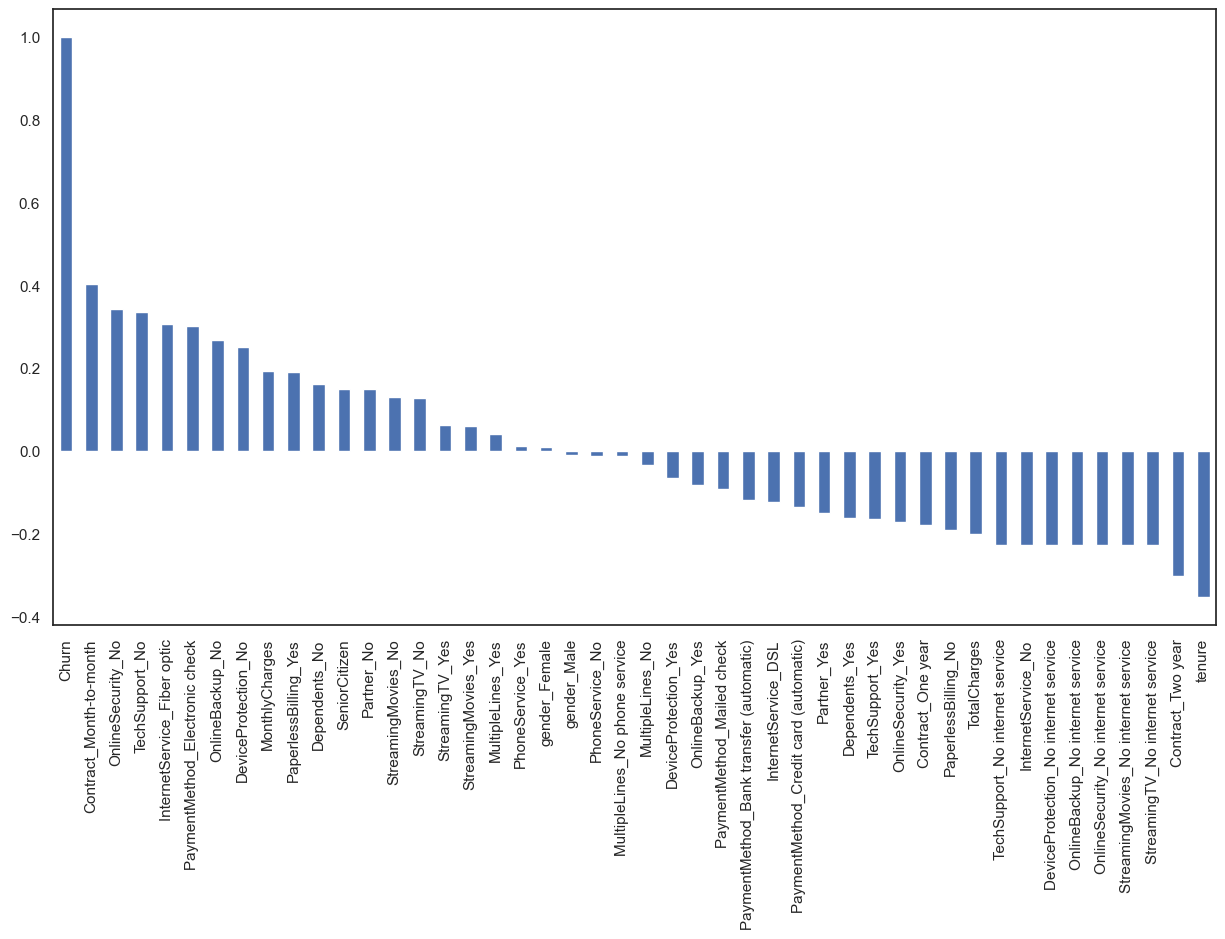

In [9]:
plt.figure(figsize=(15,8))
df_dummies.corr()['Churn'].sort_values(ascending=False).plot(kind='bar')

The correlation plot shows that month-to-month plans and no tech support/security lead to more churn. However, being a long-term customer or having a two-year contract leads to less churn. Interestingly, services like online backup and streaming TV show a negative correlation with churn specifically when there is no internet connection involved.

### Tenure

The customers taking a longer contract are more loyal to the company and tend to stay with it for a longer period of time.

Hence, lets check the effect of 'Month to Month Contract', 'One Year Contract' amd 'Two Year Contract' on the tenure

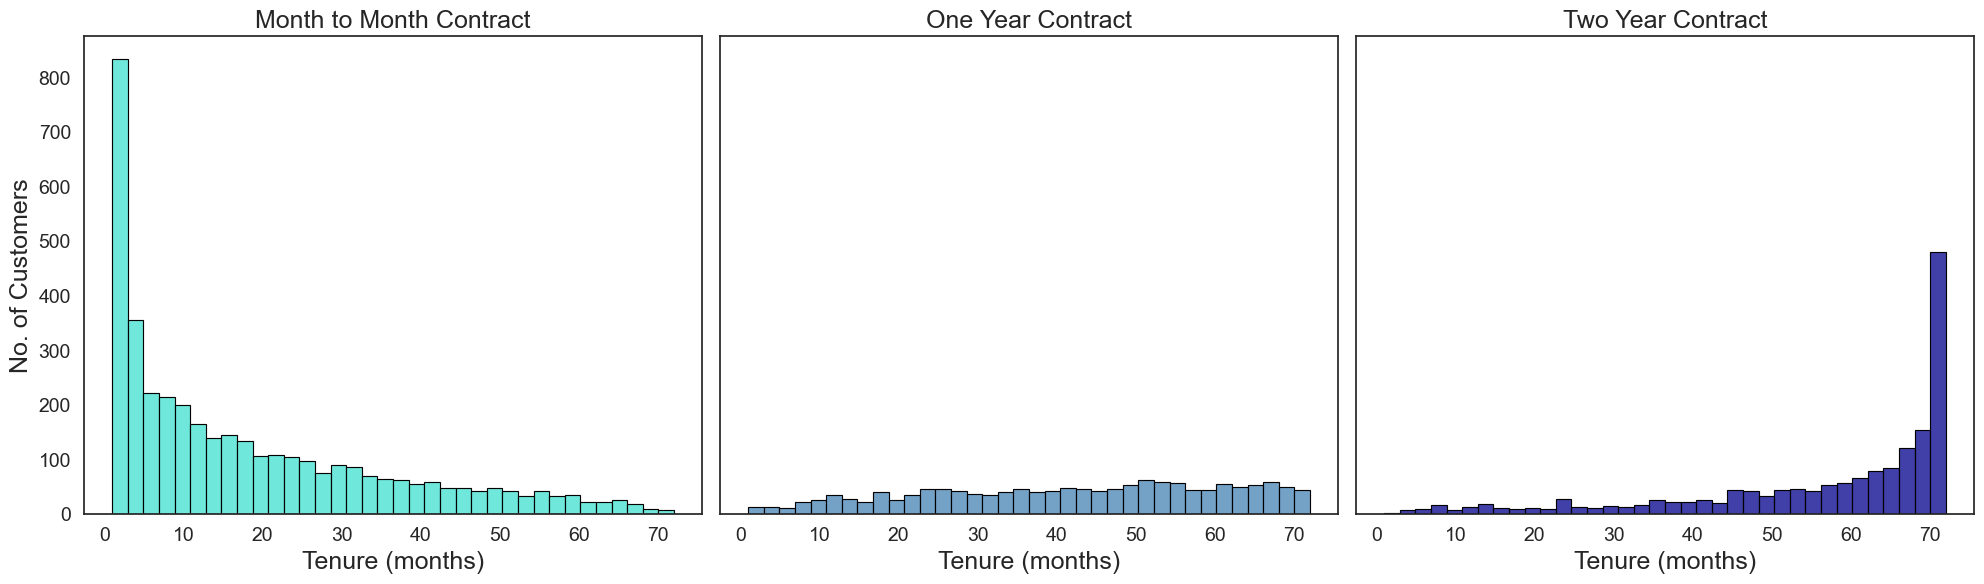

In [10]:
# Create the figure with shared Y-axis
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(20, 6))

# Month to Month Contract
sns.histplot(df[df['Contract']=='Month-to-month']['tenure'],
             kde=False, bins=int(180/5), color='turquoise',
             edgecolor='black', ax=ax1)
ax1.tick_params(labelsize=14)
ax1.set_ylabel('No. of Customers', size=18)
ax1.set_xlabel('Tenure (months)', size=18)
ax1.set_title('Month to Month Contract', size=18)

# One Year Contract
sns.histplot(df[df['Contract']=='One year']['tenure'],
             kde=False, bins=int(180/5), color='steelblue',
             edgecolor='black', ax=ax2)
ax2.tick_params(labelsize=14)
ax2.set_xlabel('Tenure (months)', size=18)
ax2.set_title('One Year Contract', size=18)

# Two Year Contract
sns.histplot(df[df['Contract']=='Two year']['tenure'],
             kde=False, bins=int(180/5), color='darkblue',
             edgecolor='black', ax=ax3)
ax3.tick_params(labelsize=14)
ax3.set_xlabel('Tenure (months)', size=18)
ax3.set_title('Two Year Contract', size=18)

plt.tight_layout()
plt.show()

Interestingly most of the monthly contracts last for 1-2 months, while the 2 year contracts tend to last for about 70 months. This shows that the customers taking a longer contract are more loyal to the company and tend to stay with it for a longer period of time.

This is also what we saw in the earlier chart on correlation with the churn rate.

###  Churn

Lets first look at the churn rate in our data

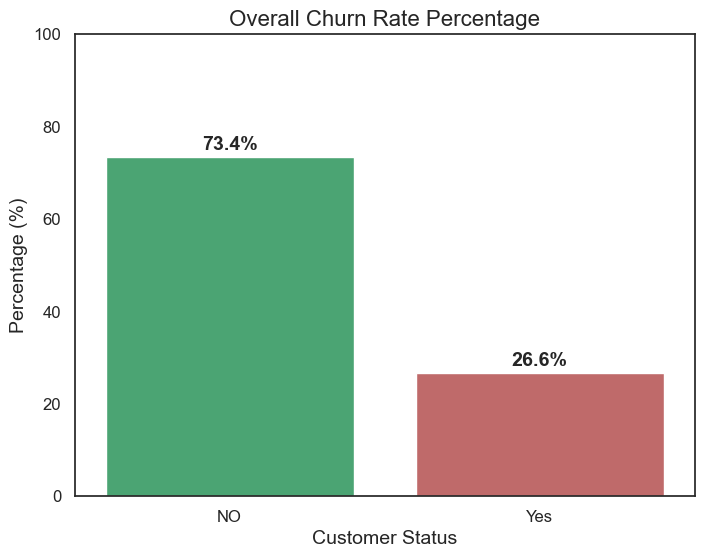

In [11]:

#Calculating the Churn Rate
churn_rate = df['Churn'].mean() * 100
stay_rate = 100 - churn_rate

#Create a small dataframe for plotting
plot_data = pd.DataFrame({
    'Status': ['NO', 'Yes'],
    'Percentage': [stay_rate, churn_rate]
})

# 3. Plotting
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Status', y='Percentage', data=plot_data, hue='Status', palette=['mediumseagreen', 'indianred'], legend=False)


# 4. Add the percentage text on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=14,
                fontweight='bold')


plt.title('Overall Churn Rate Percentage', fontsize=16)
plt.ylabel('Percentage (%)', fontsize=14)
plt.xlabel('Customer Status', fontsize=14)
plt.ylim(0, 100) # Keep scale to 100% for context
ax.tick_params(labelsize=12)

plt.show()

In our data, 73.4% of the customers do not churn. Clearly the data is skewed as we would expect a large majority of the customers to not churn.

#### i. Churn vs Tenure

<Axes: xlabel='Churn', ylabel='tenure'>

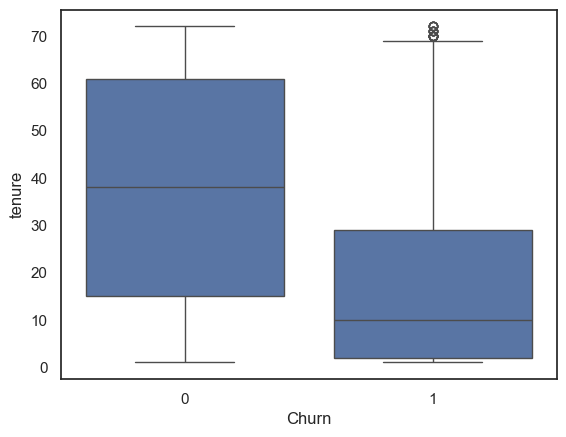

In [12]:
sns.boxplot(x=df.Churn, y=df.tenure)

As we can see form the below plot, the customers who do not churn, they tend to stay for a longer tenure with the telecom company.


#### ii. Churn by Contract Type

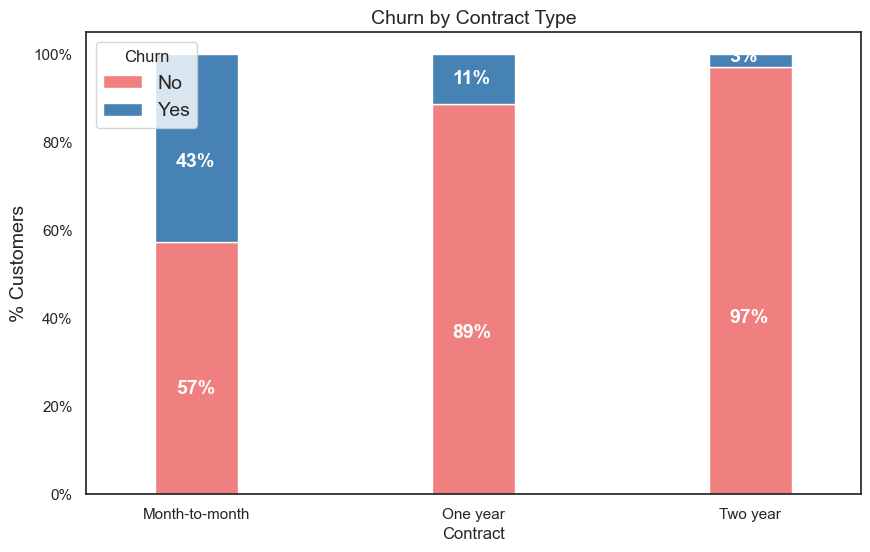

In [13]:
colors = ['lightcoral', 'steelblue']
contract_churn = df.groupby(['Contract','Churn']).size().unstack()

ax = (contract_churn.T*100.0 / contract_churn.T.sum()).T.plot(kind='bar', width = 0.3, stacked = True, rot = 0, figsize = (10,6), color = colors)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles , ['No', 'Yes'], loc='best', prop={'size':14}, title='Churn')
ax.set_ylabel('% Customers', size=14)
ax.set_title('Churn by Contract Type', size=14)

# Adding the data labels
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    ax.annotate('{:.0f}%'.format(height), (p.get_x()+.25*width, p.get_y()+.4*height), color = 'white', weight = 'bold', size = 14)

Similar to what we saw in the correlation plot, the customers who have a month to month contract have a very high churn rate.

#### iii. Churn by Monthly Charges

Text(0.5, 1.0, 'Distribution of monthly charges by churn')

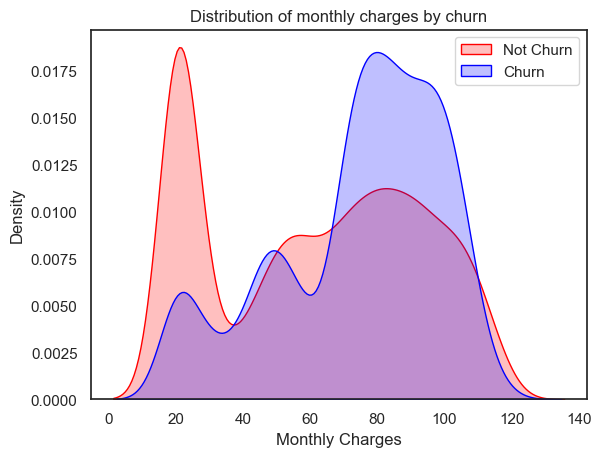

In [14]:
ax = sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 0)], color="Red", fill=True)
ax = sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 1)], ax=ax, color="Blue", fill=True)

ax.legend(["Not Churn","Churn"], loc='upper right')
ax.set_ylabel('Density')
ax.set_xlabel('Monthly Charges')
ax.set_title('Distribution of monthly charges by churn')

Higher % of customers churn when the monthly charges are high.

#### iv. Churn by Total Charges

Text(0.5, 1.0, 'Distribution of total charges by churn')

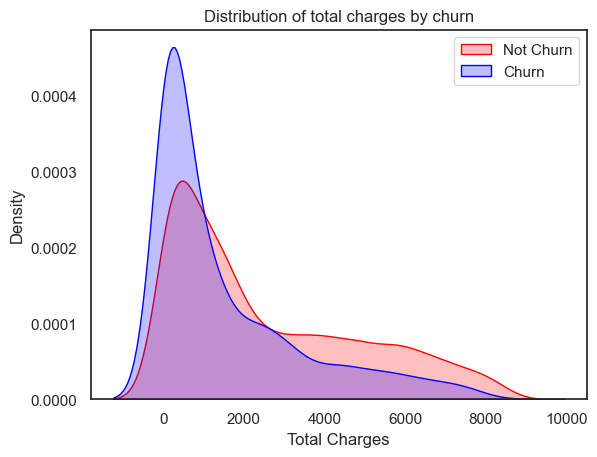

In [15]:
ax = sns.kdeplot(df.TotalCharges[(df["Churn"] == 0)], color="Red", fill=True)
ax = sns.kdeplot(df.TotalCharges[(df["Churn"] == 1)], ax=ax, color="Blue", fill=True)
ax.legend(["Not Churn","Churn"],loc='upper right')
ax.set_ylabel('Density')
ax.set_xlabel('Total Charges')
ax.set_title('Distribution of total charges by churn')

It seems that there is higer churn when the total charges are lower.

### Scaling

In [16]:
Y = df_dummies['Churn'].values
X = df_dummies.drop(columns=['Churn'])

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

X_train = X_train.copy()
X_test = X_test.copy()

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_cols] = X_train[num_cols].astype(float)
X_test[num_cols] = X_test[num_cols].astype(float)

scaler = MinMaxScaler(feature_range=(0, 1))

X_train.loc[:, num_cols] = scaler.fit_transform(X_train[num_cols])
X_test.loc[:, num_cols] = scaler.transform(X_test[num_cols])


While doing preprocessing, I faced a few small problems and fixed them before moving to the ANN model. At first, I scaled the full dataset before splitting it into train and test data, but I later understood that this was not the correct order, so I changed it by splitting the data first and then scaling only the training data before applying the same scaling to the test data. I also got a warning while updating the scaled columns, so I fixed that by making proper copies of the train and test datasets before changing the values. After these changes, my preprocessing step became more correct and ready for model building.

In [17]:
print(f'X_train: {X_train.shape}, y_train: {Y_train.shape}')
print(f'X_test: {X_test.shape}, y_test: {Y_test.shape}')

# Lets have a look at our training datatset
X_train.sample(5)


X_train: (5625, 45), y_train: (5625,)
X_test: (1407, 45), y_test: (1407,)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
672,0,0.000000,0.565087,0.006491,True,False,True,False,True,False,...,False,True,False,False,False,True,False,False,False,True
5486,0,0.746479,0.685287,0.544242,False,True,True,False,True,False,...,True,False,False,True,True,False,True,False,False,False
1296,1,0.267606,0.621446,0.184099,True,False,True,False,True,False,...,False,True,False,False,True,False,True,False,False,False
6381,0,0.000000,0.011471,0.000087,False,True,True,False,False,True,...,False,True,False,False,True,False,False,False,False,True
3617,1,0.239437,0.298753,0.091380,True,False,False,True,True,False,...,True,True,False,False,False,True,False,False,True,False


### Model

Building a simple feet-forward neural network

Accuracy:  0.7982

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.66      0.49      0.57       374

    accuracy                           0.80      1407
   macro avg       0.75      0.70      0.72      1407
weighted avg       0.79      0.80      0.79      1407



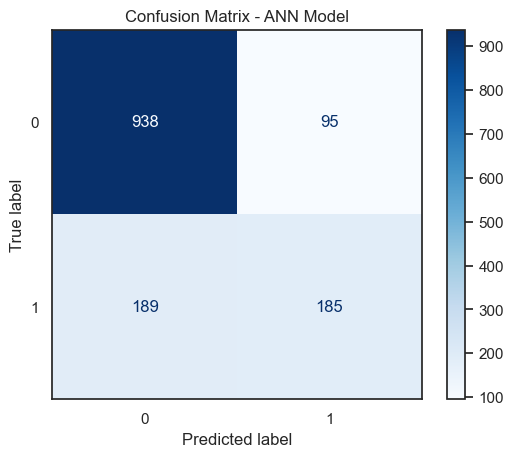

In [18]:
ann_model = MLPClassifier(hidden_layer_sizes=(16,8),
                        activation='relu',
                        solver='adam',
                        max_iter=300,
                        random_state=42,
                        early_stopping=True,
                        validation_fraction=0.1,
                        n_iter_no_change=10)

#Train
ann_model.fit(X_train,Y_train)

#Prediction
Y_pred = ann_model.predict(X_test)

#Evaluate
accuracy = accuracy_score(Y_test, Y_pred)
print('Accuracy: ', round(accuracy, 4))
print("\nClassification Report:\n")
print(classification_report(Y_test, Y_pred))

#Confusion_Matrix
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - ANN Model")
plt.show()



The confusion matrix shows that the model correctly classified 938 non-churn customers and 185 churn customers. It performs much better for the non-churn class than for the churn class, which indicates class-wise imbalance in prediction quality. The model missed 189 actual churn customers by predicting them as non-churn, which is a significant limitation. This means the ANN is reasonably good overall, but it may fail to identify many customers who are actually at risk of leaving.

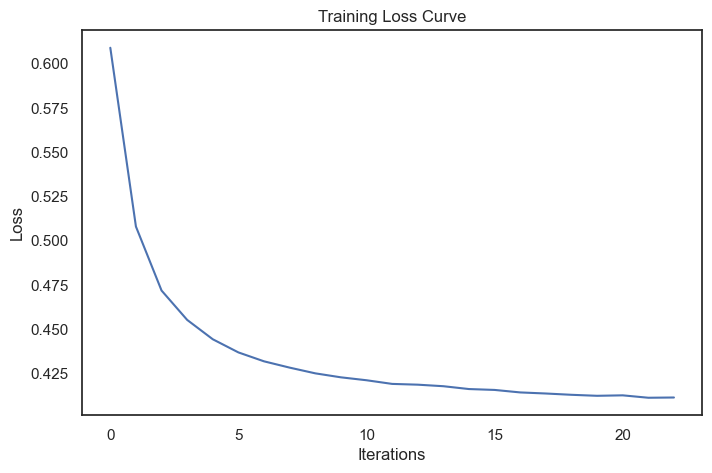

In [19]:
plt.figure(figsize=(8,5))
plt.plot(ann_model.loss_curve_)
plt.title("Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()


The training loss curve shows a sharp decrease in loss during the initial iterations, which indicates that the model quickly learned important patterns from the data. After that, the loss decreases more gradually and begins to stabilize. This suggests that the ANN is converging properly and improving its predictions over time. The smooth downward trend also indicates that the model is training effectively without major instability.

## Conclusion

This project was done to predict customer churn using a telecom dataset and to understand which factors are related to customers leaving the service. The data was cleaned, encoded, and scaled before training a simple feedforward neural network. From the analysis, features like contract type, tenure, monthly charges, and internet service were found to be important for churn prediction. The model gave 80% accuracy, but it performed better for non-churn customers than churn customers and missed some actual churn cases. Overall, the model worked as a good basic model and can help the company identify risky customers.